**Imports**

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import itertools
import json
import seaborn as sns

**Choosing dataset**

In [ ]:
train_dir = "/content/drive/MyDrive/dataset/train"
test_dir = "/content/drive/MyDrive/dataset/test"

**10 images per batch, using 224x224 resolution to save resources**

In [ ]:
batch_size = 10
img_size = (224, 224)


**80%/20% split for training and validation data**

In [ ]:
train_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

val_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=False
)

Found 58347 files belonging to 25 classes.
Using 46678 files for training.
Found 58347 files belonging to 25 classes.
Using 11669 files for validation.
Found 8016 files belonging to 25 classes.


In [ ]:
class_names = list(train_ds.class_names)
with open("/content/drive/MyDrive/classV2_names.json", "w") as f:
    json.dump(class_names, f)
num_classes = len(train_ds.class_names)

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

#Transfer learning


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

# Build model
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.1)(x)
x = layers.Conv2D(num_classes, (1, 1), activation='linear')(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Activation('softmax')(x)
model = tf.keras.Model(inputs, outputs)

**Compile model**

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

## Callbacks: early stopping and learning rate reduction.

In [ ]:
earlystop_cb = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=0.0001)

**Train model**

In [ ]:
initial_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[earlystop_cb, reduce_lr_cb]
)

Epoch 1/10
4668/4668 ━━━━━━━━━━━━━━━━━━━━ 99s 20ms/step - accuracy: 0.7491 - loss: 0.9475 - val_accuracy: 0.8281 - val_loss: 0.6020 - learning_rate: 0.0100
Epoch 2/10
4668/4668 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - accuracy: 0.8110 - loss: 0.6527 - val_accuracy: 0.8283 - val_loss: 0.6823 - learning_rate: 0.0100
Epoch 3/10
4668/4668 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.8171 - loss: 0.6630 - val_accuracy: 0.8301 - val_loss: 0.6947 - learning_rate: 0.0100
Epoch 4/10
4668/4668 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.8636 - loss: 0.4264 - val_accuracy: 0.8866 - val_loss: 0.3427 - learning_rate: 1.0000e-03
Epoch 5/10
4668/4668 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.8859 - loss: 0.3228 - val_accuracy: 0.8936 - val_loss: 0.3172 - learning_rate: 1.0000e-03
Epoch 6/10
4668/4668 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.8951 - loss: 0.2912 - val_accuracy: 0.8973 - val_loss: 0.3053 - learning_rate: 1.0000e-03
Epoch 7/10
4668/4668 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - 

Fine tuning

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False

# Re-compile with lower LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[earlystop_cb, reduce_lr_cb]
)

Epoch 1/10
4668/4668 ━━━━━━━━━━━━━━━━━━━━ 81s 13ms/step - accuracy: 0.8230 - loss: 0.6206 - val_accuracy: 0.8928 - val_loss: 0.3403 - learning_rate: 1.0000e-04
Epoch 2/10
4668/4668 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - accuracy: 0.9316 - loss: 0.1956 - val_accuracy: 0.9092 - val_loss: 0.3778 - learning_rate: 1.0000e-04
Epoch 3/10
4668/4668 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - accuracy: 0.9586 - loss: 0.1204 - val_accuracy: 0.9236 - val_loss: 0.2764 - learning_rate: 1.0000e-04
Epoch 4/10
4668/4668 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9706 - loss: 0.0892 - val_accuracy: 0.9387 - val_loss: 0.2310 - learning_rate: 1.0000e-04
Epoch 5/10
4668/4668 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - accuracy: 0.9784 - loss: 0.0646 - val_accuracy: 0.9275 - val_loss: 0.3141 - learning_rate: 1.0000e-04
Epoch 6/10
4668/4668 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - accuracy: 0.9818 - loss: 0.0528 - val_accuracy: 0.9457 - val_loss: 0.2464 - learning_rate: 1.0000e-04
Epoch 7/10
4668/4668 ━━━━━━━━━━━━━━━━━━━

**Evaluation**

In [ ]:
train_loss,train_acc = model.evaluate(train_ds)

4668/4668 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - accuracy: 0.9807 - loss: 0.0733


In [ ]:
print(train_loss,train_acc)

0.06754724681377411 0.981897234916687


In [ ]:
val_loss,val_acc = model.evaluate(val_ds)

1167/1167 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9537 - loss: 0.2086


In [ ]:
print(val_loss,val_acc)

0.20775409042835236 0.9550089836120605


**Save**

In [ ]:
model.save("/content/drive/MyDrive/capstone/plant_modelV2_transfer.h5")

**Plot graph**

In [ ]:
combined_history = {
    'accuracy': initial_history.history['accuracy'] + fine_tune_history.history['accuracy'],
    'val_accuracy': initial_history.history['val_accuracy'] + fine_tune_history.history['val_accuracy'],
    'loss': initial_history.history['loss'] + fine_tune_history.history['loss'],
    'val_loss': initial_history.history['val_loss'] + fine_tune_history.history['val_loss'],
}

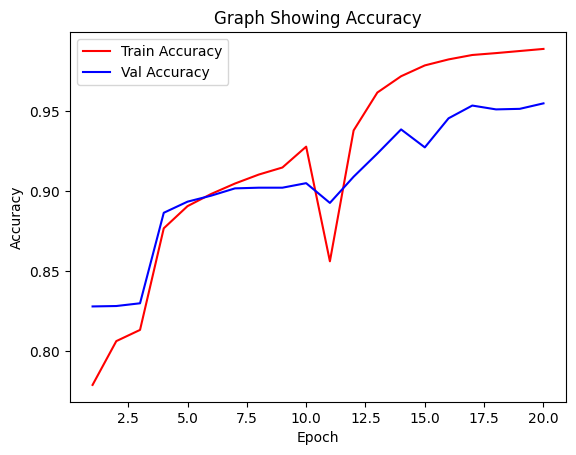

In [ ]:
epochs_range = range(1, len(combined_history['accuracy']) + 1)

plt.plot(epochs_range, combined_history['accuracy'], label='Train Accuracy', color='red')
plt.plot(epochs_range, combined_history['val_accuracy'], label='Val Accuracy', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Graph Showing Accuracy')
plt.legend()
plt.show()


In [ ]:
combined_loss = initial_history.history['loss'] + fine_tune_history.history['loss']
combined_val_loss = initial_history.history['val_loss'] + fine_tune_history.history['val_loss']

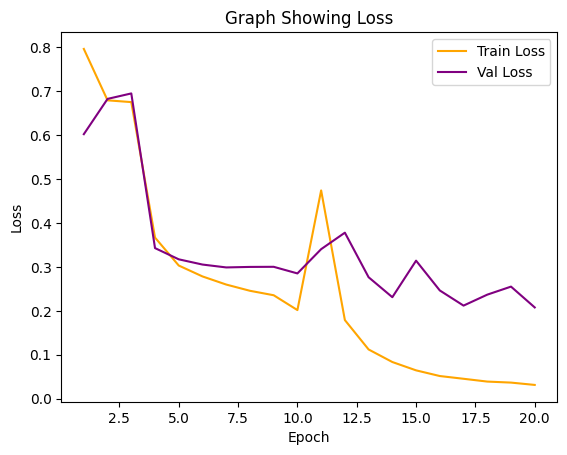

In [ ]:
epochs_range = range(1, len(combined_loss) + 1)

plt.plot(epochs_range, combined_loss, label='Train Loss', color='orange')
plt.plot(epochs_range, combined_val_loss, label='Val Loss', color='purple')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Graph Showing Loss')
plt.legend()
plt.show()

In [ ]:
model = tf.keras.models.load_model('/content/drive/MyDrive/capstone/plant_modelV2_transfer.h5')

Confusion matrix

Classification Report:
                                                     precision    recall  f1-score   support

          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      1.00       387
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       429
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.98      0.96      0.97       371
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       413
               Corn_(maize)___Northern_Leaf_Blight       0.96      0.98      0.97       445
                            Corn_(maize)___healthy       1.00      0.92      0.96       413
                     Pepper,_bell___Bacterial_spot       1.00      0.97      0.99       441
                            Pepper,_bell___healthy       0.97      1.00      0.98       459
                             Potato___Early_blight       0.99      1.00      1.00       455
                              Potato___Late_blight     

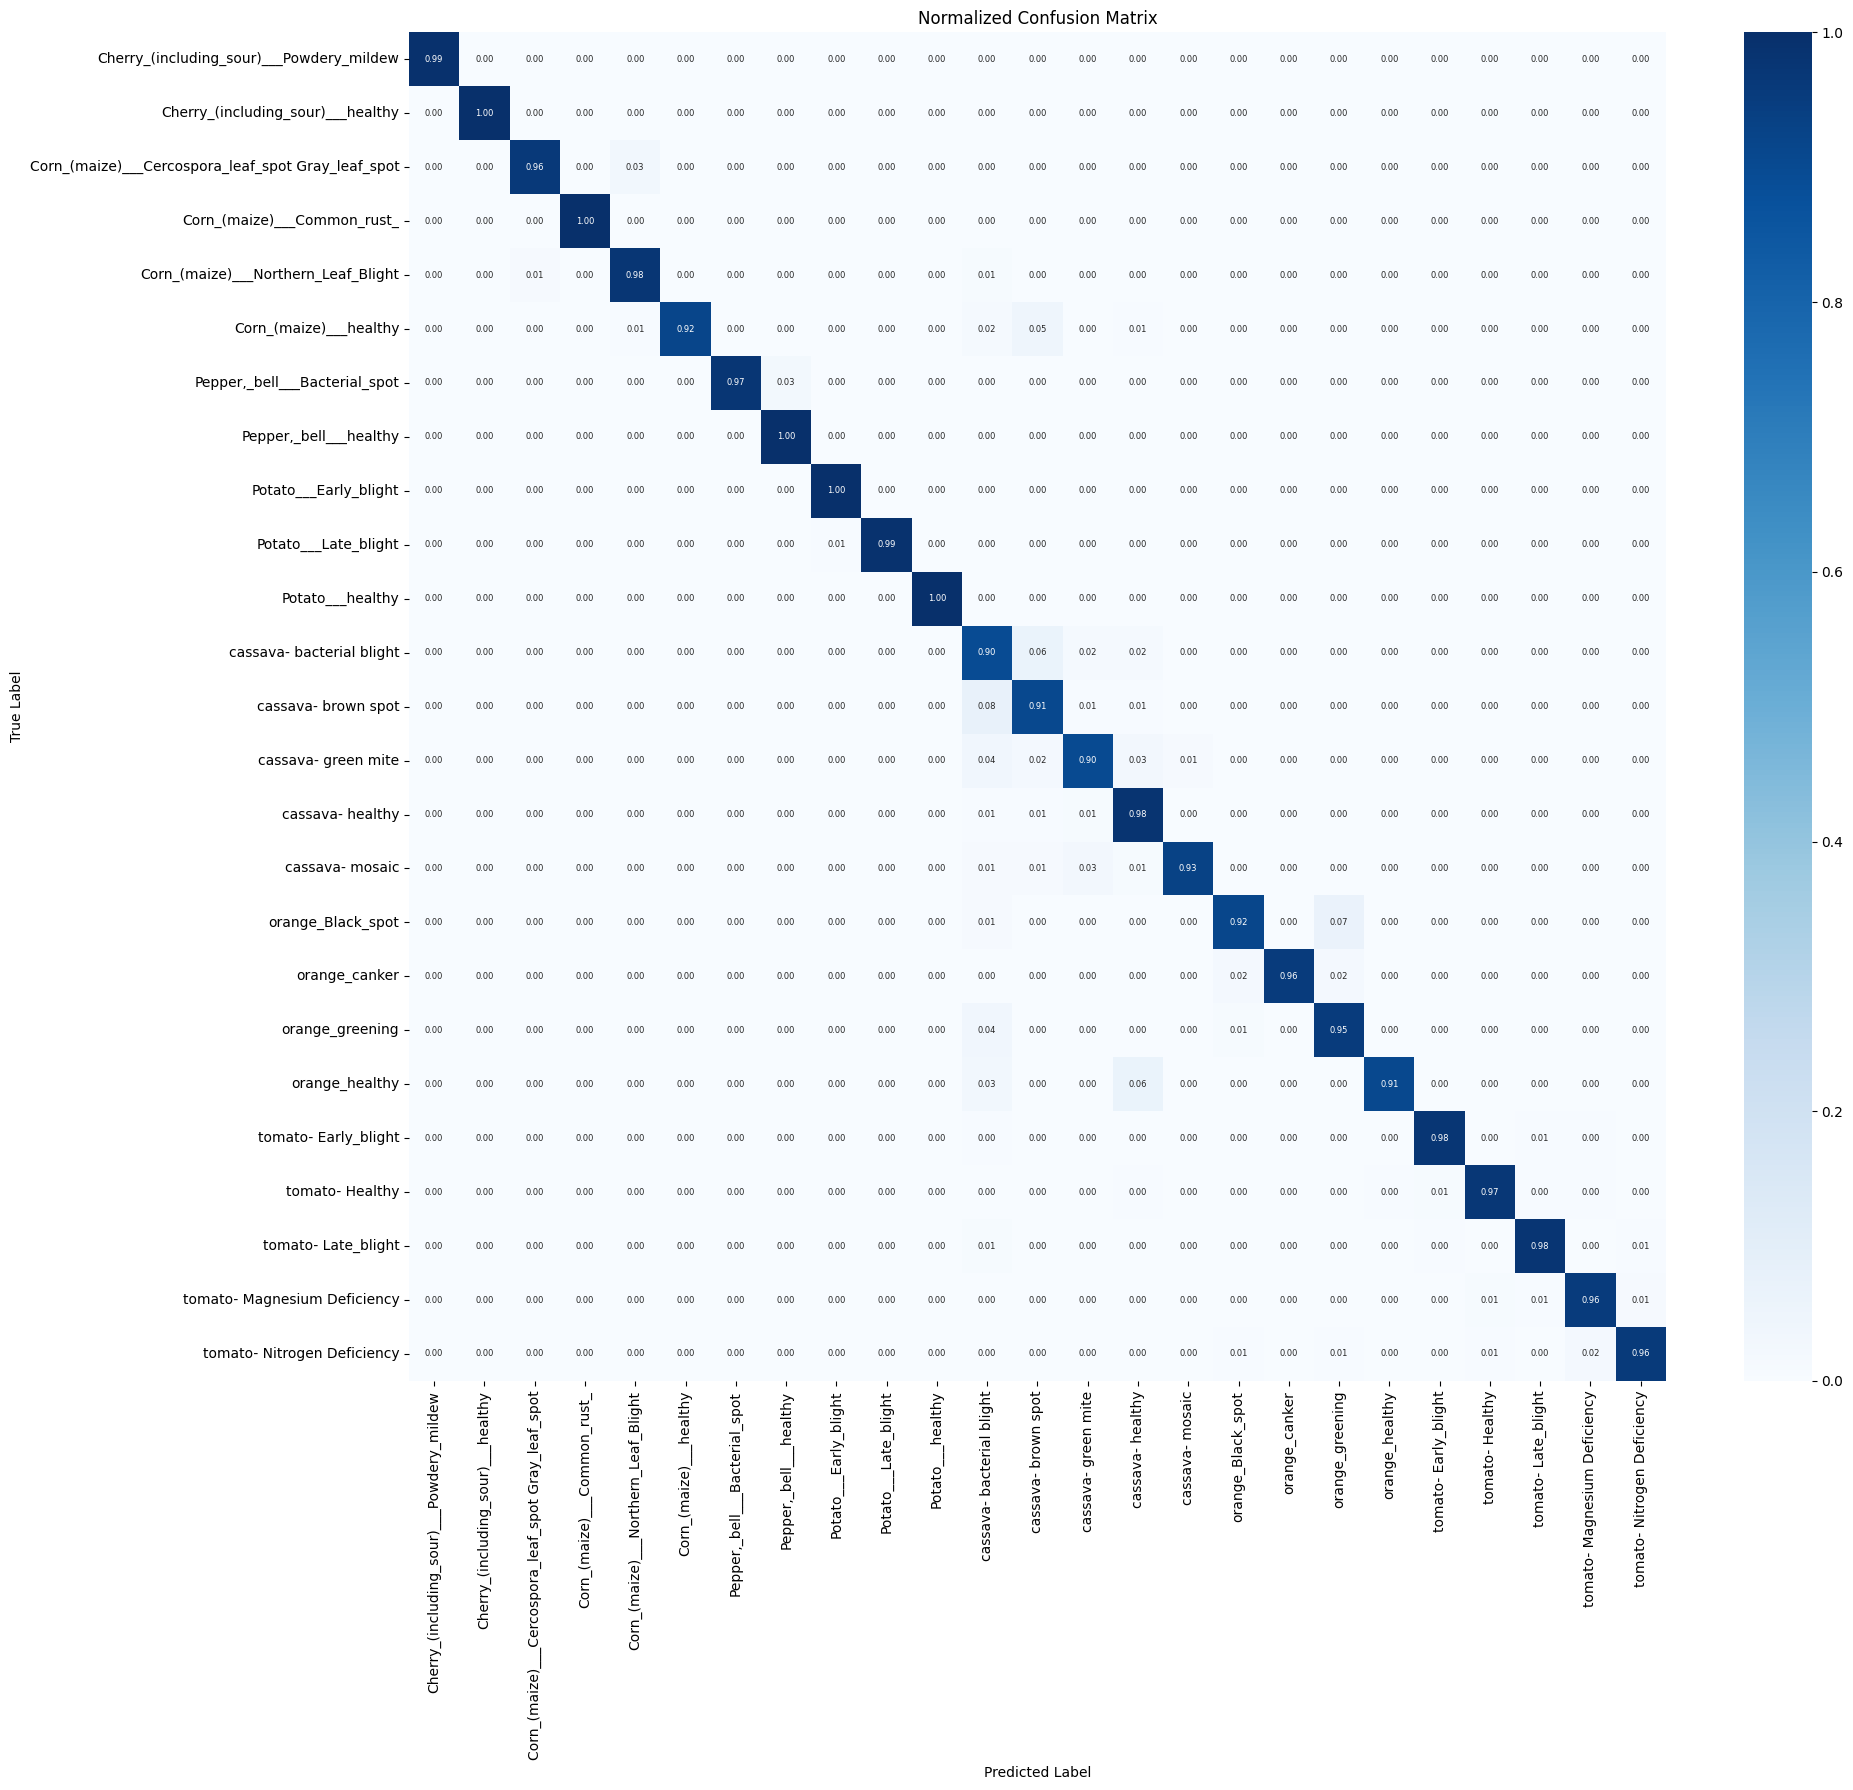

In [ ]:
def get_report(dataset, class_names):
    y_true = []
    y_pred = []

    for batch in dataset:
        images, labels = batch
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names)
    print("Classification Report:\n", report)
    plot_con_matrix(cm, classes=class_names, normalize=True)


def plot_con_matrix(cm, classes, normalize=True, title='Normalized Confusion Matrix'):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm = np.nan_to_num(cm)

    plt.figure(figsize=(20, 18))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                annot_kws={"size": 6})
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

get_report(val_ds, class_names)